# Image Files with OpenCV

*Learn to load a supplied image, convert it to grayscale, save it, and reopen the result with OpenCV.*

This lesson keeps image processing deliberately small. The emphasis is the image-file I/O cycle, with grayscale conversion as the only saved modification.


## Before You Run

In the course JupyterLite site, choose **Add files**, select `study_workspace.png`, and enter `assets/06_image_files` for **Save folder**. The site creates missing folders and stores the file as `/home/pyodide/assets/06_image_files/study_workspace.png`.

An upload-window relative folder starts at `/home/pyodide`. A relative path inside Python starts at the current working directory set in the first code cell.


## Setting Input and Output Directories

Set the JupyterLite base and locate the polished color image in its numbered upload folder. The grayscale result is saved in `outputs/06_image_files`.


In [1]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

jupyterlite_base_directory = "/home/pyodide"
chapter_name = "01-3_Python_Basics_III"
launch_directory = os.getcwd()

if os.path.isdir(jupyterlite_base_directory):
    base_directory = jupyterlite_base_directory
elif os.path.basename(launch_directory) == chapter_name:
    base_directory = launch_directory
else:
    base_directory = os.path.join(launch_directory, chapter_name)

if not os.path.isdir(base_directory):
    raise FileNotFoundError(f"Base directory not found: {base_directory}")

os.chdir(base_directory)

input_directory = os.path.join(base_directory, "assets", "06_image_files")
input_path = os.path.join(input_directory, "study_workspace.png")

assert os.path.isfile(input_path), (
    "Add study_workspace.png and set Save folder to assets/06_image_files."
)

output_directory = os.path.join(base_directory, "outputs", "06_image_files")
os.makedirs(output_directory, exist_ok=True)
output_path = os.path.join(output_directory, "study_workspace_grayscale.png")

print("JupyterLite base:", jupyterlite_base_directory)
print("Current directory name:", os.path.basename(os.getcwd()))
print("Input folder:", os.path.relpath(input_directory, base_directory))
print("Input file:", os.path.basename(input_path))
print("Output folder:", os.path.relpath(output_directory, base_directory))
print("Output directory exists:", os.path.isdir(output_directory))


JupyterLite base: /home/pyodide
Current directory name: 01-3_Python_Basics_III
Input folder: assets/06_image_files
Input file: study_workspace.png
Output folder: outputs/06_image_files
Output directory exists: True


Input and output paths are separate, so the supplied image cannot be overwritten by the example.


## Loading the Color Image

`cv2.imread()` loads the file into a NumPy array. OpenCV uses BGR channel order for color images, so always check that loading returned an array rather than `None`.


In [2]:
color_image = cv2.imread(input_path, cv2.IMREAD_COLOR)

if color_image is None:
    raise ValueError(f"OpenCV could not load: {os.path.basename(input_path)}")

height, width, channel_count = color_image.shape
print("Image size:", width, "x", height)
print("Color channels:", channel_count)
print("Array dtype:", color_image.dtype)


Image size: 900 x 600
Color channels: 3
Array dtype: uint8


The supplied PNG loads as a 900 by 600 array with three BGR color channels and 8-bit pixel values.


## Displaying the Loaded Image

Matplotlib expects RGB order. Convert BGR to RGB only for correct display; this display array is not saved as a separate transformation.


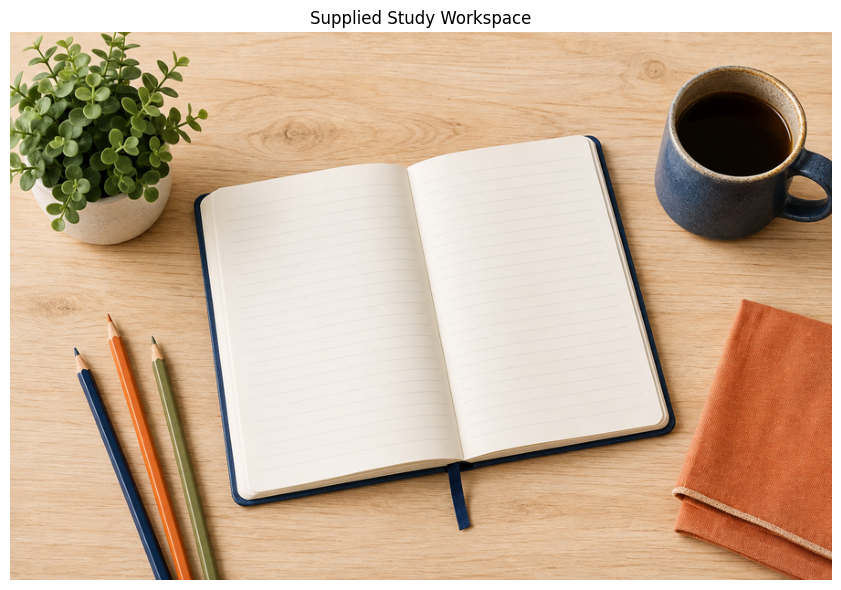

In [3]:
display_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 6))
plt.imshow(display_image)
plt.title("Supplied Study Workspace")
plt.axis("off")
plt.tight_layout()
plt.show()


The displayed image is the committed input asset. No resize, crop, drawing, or format conversion is applied.


## Converting and Saving Grayscale

`cv2.cvtColor()` creates a one-channel grayscale array. `cv2.imwrite()` saves that array to the prepared output path and returns whether writing succeeded.


Saved file: study_workspace_grayscale.png
Saved successfully: True
Grayscale shape: (600, 900)


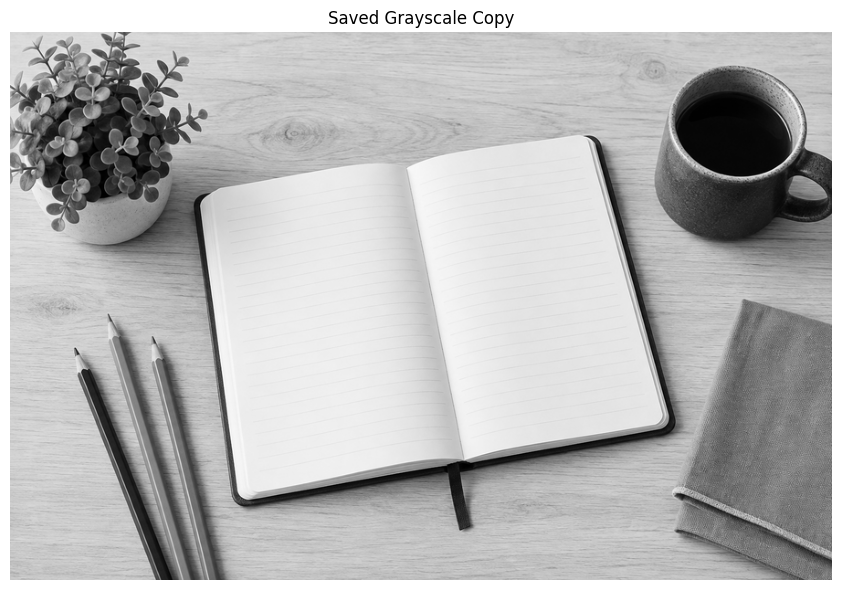

In [4]:
grayscale_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2GRAY)
save_succeeded = cv2.imwrite(output_path, grayscale_image)

if not save_succeeded:
    raise OSError(f"OpenCV could not save: {os.path.basename(output_path)}")

print("Saved file:", os.path.basename(output_path))
print("Saved successfully:", save_succeeded)
print("Grayscale shape:", grayscale_image.shape)

plt.figure(figsize=(9, 6))
plt.imshow(grayscale_image, cmap="gray", vmin=0, vmax=255)
plt.title("Saved Grayscale Copy")
plt.axis("off")
plt.tight_layout()
plt.show()


The grayscale copy keeps the original 900 by 600 dimensions. Grayscale conversion is the only saved image modification in this lesson.


## Reopening the Saved Image

Load the new file in grayscale mode and compare its pixel array with the array passed to `cv2.imwrite()`.


In [5]:
reloaded_image = cv2.imread(output_path, cv2.IMREAD_GRAYSCALE)

if reloaded_image is None:
    raise ValueError(f"OpenCV could not reload: {os.path.basename(output_path)}")

print("Reloaded shape:", reloaded_image.shape)
print("Saved pixels match:", np.array_equal(reloaded_image, grayscale_image))
print("Output exists:", os.path.isfile(output_path))


Reloaded shape: (600, 900)
Saved pixels match: True
Output exists: True


The reopened array has the expected shape and identical pixel values, confirming the grayscale PNG round trip.


## Use Cases

The same load-save-verify pattern supports prepared image datasets, document scans, and preprocessing pipelines while preserving original assets.


Build separate input and output paths, load with `cv2.imread()`, check for `None`, convert only with `cv2.cvtColor(..., cv2.COLOR_BGR2GRAY)`, save with `cv2.imwrite()`, and reopen the result to verify it.
